In [1]:
%reload_ext autoreload
%autoreload 2

import os, glob, sys
import pandeia.engine
import stsynphot
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import numpy as np
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib as mpl
from rsg import rsg_phot
from tqdm import tqdm
import copy
import pandas as pd
%matplotlib inline

### MARCS models

In [2]:
syn_rsg = rsg_phot()
rsgspec = syn_rsg.create_rsg(0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 16.07 * u.Mpc)
filts = ['f090w', 'f115w', 'f150w', 'f164n', 'f182m', 'f187n', 'f200w', 'f210m', 'f212n', 'f277w', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']
rsgmag = syn_rsg.compute_rsg_mag(filts, 0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 13.0 * u.Mpc)

In [3]:
wvs = rsgspec.waveset
rsgspec(wvs)

<Quantity [2.42837812e-10, 4.08509627e-10, 2.54871705e-10, ...,
           1.54747196e-09, 1.60105752e-09, 1.51308831e-09] PHOTLAM>

Text(0, 0.5, 'photlam $(\\text{photons}/\\text{s}/\\text{cm}^2/\\AA)$')

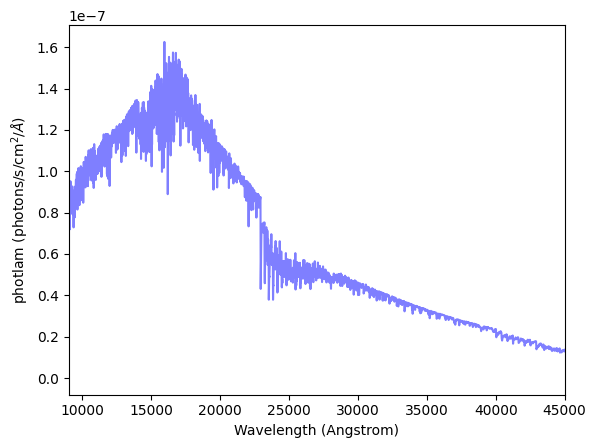

In [4]:
wvs = rsgspec.waveset
plt.plot(wvs, rsgspec(wvs), color = 'blue', alpha = 0.5)
plt.xlim(9000, 45000)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel(r'photlam $(\text{photons}/\text{s}/\text{cm}^2/\AA)$')

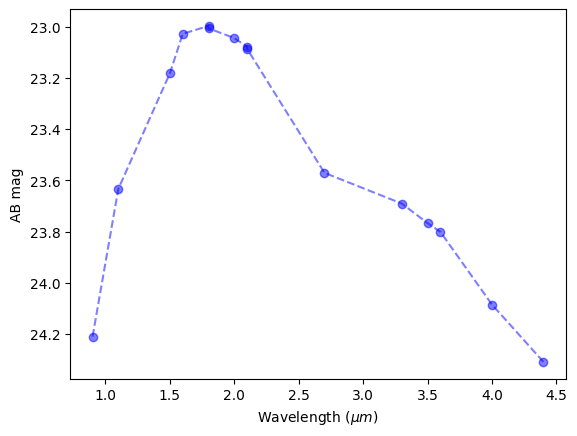

In [5]:
wvs = [float(i[1:3])/10 for i in filts]
mags = [rsgmag[flt].value for flt in filts]
plt.plot(wvs, mags, color = 'blue', alpha = 0.5, marker = 'o', linestyle = '--')
plt.xlabel(r'Wavelength (${\mu}m$)')
plt.ylabel('AB mag')
plt.gca().invert_yaxis()

In [ ]:
params = ['lum', 'tau', 'temp']
filts = ['f090w', 'f115w', 'f150w', 'f164n', 'f187n', 'f200w', 'f212n', 'f277w', 'f300m', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']
modeldf = pd.DataFrame(columns=params+filts)
syn_rsg = rsg_phot()
rsg_temps = np.linspace(3000, 5000, 11) * u.K
taus = np.linspace(0.01, 5, 11)
lums = np.linspace(4, 5, 11) * u.Lsun

for lum in tqdm(lums):
    for tau in taus:
        for temp in rsg_temps:
            try:
                rsgmag = syn_rsg.compute_rsg_mag(filts, tau, lum, temp, 1000 * u.K, 12.474*u.Mpc)
                modeldf.loc[len(modeldf)] = [lum.value, tau, temp.value] + [i.value for i in rsgmag.values()]
            except:
                 modeldf.loc[len(modeldf)] = [lum.value, tau, temp.value] + [np.nan]*len(filts)

100%|██████████| 11/11 [08:19<00:00, 45.37s/it]


In [6]:
modeldf = pd.read_csv('data/dolphot/ngc5643/ngc5643_marcs.csv')

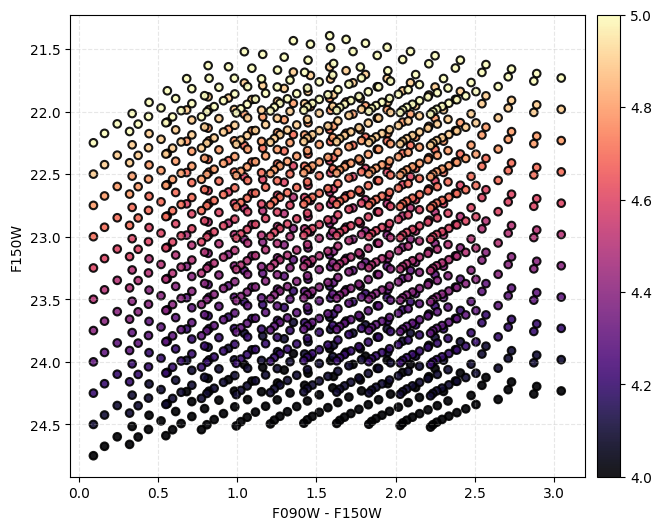

In [9]:
flt_1, flt_2 = 'f090w', 'f150w'
plt.figure(figsize = (8, 6))
plt.scatter(modeldf[flt_1]-modeldf[flt_2], modeldf[flt_2], marker='o', s=30, c=np.repeat(lums.value, 121),
            cmap='magma', edgecolors='black', lw=1.5, alpha=0.9)
plt.colorbar(pad = 0.02)
plt.xlabel(f'{flt_1.upper()} - {flt_2.upper()}')
plt.ylabel(f'{flt_2.upper()}')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, linestyle='--')

### dolphot catalogs

In [10]:
cat = None
for fl in glob.glob('data/dolphot/ngc5643/proc/ngc5643_0_*.csv'):
    if cat is None:
        cat = pd.read_csv(fl)
    else:
        df_ = pd.read_csv(fl)
        cat = pd.concat([cat, df_])
cat.reset_index(inplace=True)

In [11]:
def lin(x, m, c):
    return m*x+c

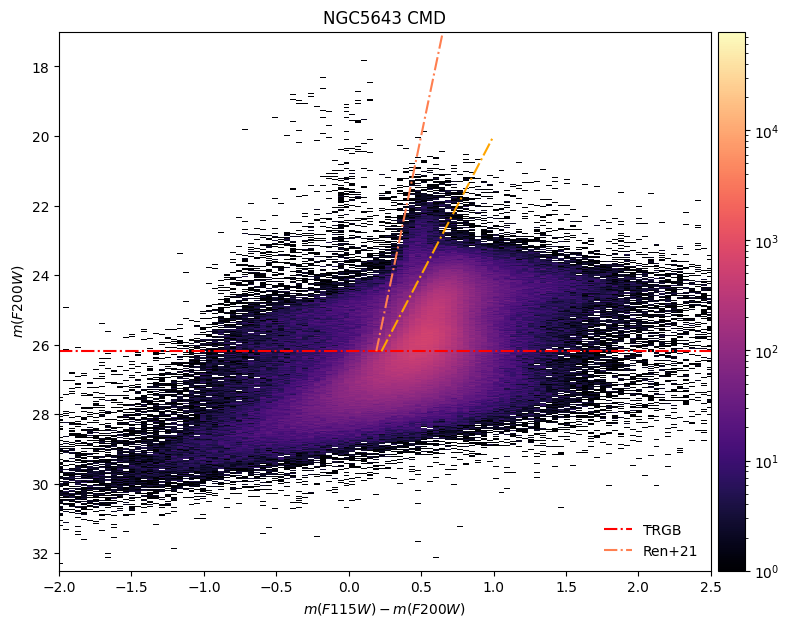

In [12]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']

hist = ax.hist2d(cl, m, bins = 4000, norm = 'log', cmap = 'magma')
# ax.scatter(modeldf[f1.lower()] - modeldf[f2.lower()], modeldf[f2.lower()], marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
#             cmap='viridis', edgecolors='black', lw=1.5, alpha=0.8, label = 'RSG Model')

ax.axhline(26.19, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -8.0, 25+3), linestyle='-.', color = 'orange')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.set_xlim(-2, 2.5)
ax.set_ylim(32.5, 17)
plt.show()

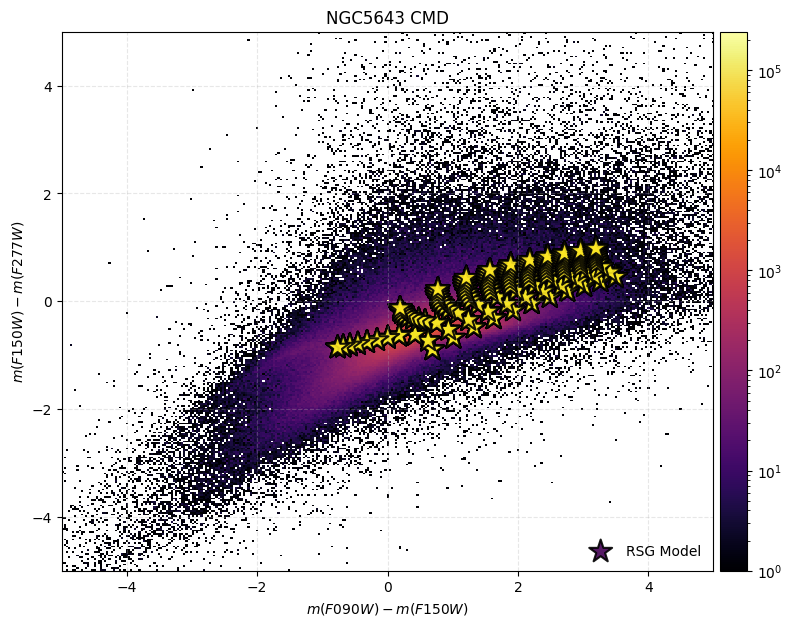

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2, f3 = 'F090W', 'F150W', 'F277W'

cl, m = cat[f1+'_mag'] - cat[f3+'_mag'], cat[f2+'_mag'] - cat[f3+'_mag']

hist = ax.hist2d(cl, m, bins = 5000, norm = 'log', cmap = 'inferno')
ax.scatter(modeldf[f1.lower()] - modeldf[f3.lower()], modeldf[f2.lower()] - modeldf[f3.lower()], marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9, label = 'RSG Model')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2}) - m({f3})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.show()

In [13]:
jwst_wv = np.array([0.9, 1.15, 1.5, 1.64, 1.87, 2, 2.12, 2.77, 3, 3.35, 3.56, 3.6, 4.05, 4.44])

Text(0, 0.5, 'AB Mag')

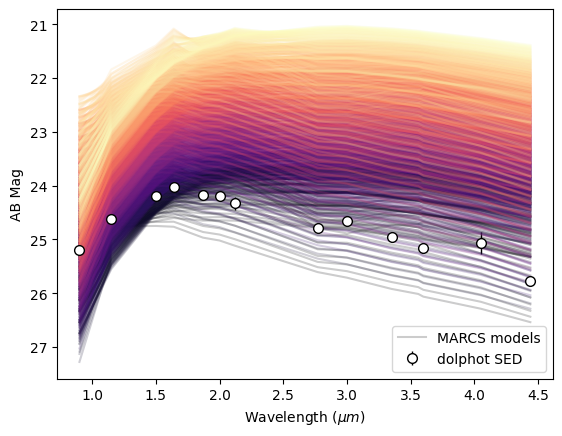

In [ ]:
# rsg_mask = (m<23) & (cl > 1) & (cl < 2)
rsg_mask = (m<25) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3))
idx = cat[rsg_mask].sample(1).index[0]
st = cat.loc[idx].to_numpy()
mag, magerr = st[7:21], st[21:]
nanmask = (mag>99) | (magerr>9)
mag[nanmask], magerr[nanmask] = np.nan, np.nan
fig, ax = plt.subplots(1, 1)
ax.errorbar(x=jwst_wv, y=mag, yerr=magerr, marker='o', markerfacecolor='white', markeredgecolor='black', 
            markersize=7, lw=0, ecolor='black', elinewidth=1, label = 'dolphot SED')

n_lines = 1331
c = np.arange(1, n_lines + 1)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.magma)
cmap.set_array([])

for i, midx in enumerate(modeldf.index):
    model_st = modeldf.iloc[midx][filts].to_numpy().flatten()
    if i==0:
        ax.plot(jwst_wv, model_st, c=cmap.to_rgba(i+1), markeredgecolor = 'black', alpha = 0.2, label = 'MARCS models')
    else:
        ax.plot(jwst_wv, model_st, c=cmap.to_rgba(i+1), markeredgecolor = 'black', alpha = 0.2)

plt.gca().invert_yaxis()
plt.legend()
plt.xlabel(r'Wavelength $(\mu m)$')
plt.ylabel('AB Mag')
# plt.savefig('plots/sed.png', bbox_inches = 'tight')

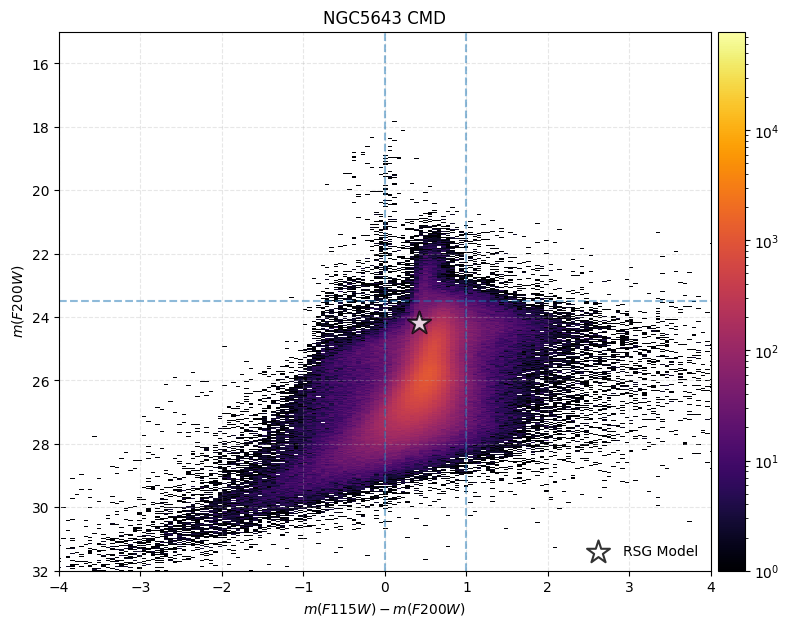

In [19]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']

hist = ax.hist2d(cl, m, bins = 3000, norm = 'log', cmap = 'inferno')
ax.scatter(cat.loc[idx]['F115W_mag']-cat.loc[idx]['F200W_mag'], cat.loc[idx]['F200W_mag'], marker='*', s=300, facecolor='white', edgecolor='black', lw=1.5, alpha=0.8, label = 'RSG Model')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-4, 4)
ax.set_ylim(32, 15)
plt.axhline(23.5, linestyle='--', alpha=0.5)
plt.axvline(0, alpha=0.5, linestyle='--')
plt.axvline(1, alpha=0.5, linestyle='--')
plt.show()

In [128]:
rsg_mask.sum()

np.int64(15176)

### GP model

In [20]:
import george
from george import kernels
from sklearn.exceptions import ConvergenceWarning
import warnings

In [21]:
def fit_gp_model_george(wvs, mags, err, min_len_scale=1):

    # kernel = kernels.Matern52Kernel(metric = [min_len_scale**2], bounds = [[np.min(mags) - 5,np.max(mags)  + 5]])
    kernel = kernels.RationalQuadraticKernel(log_alpha=0.4, metric=min_len_scale)
    gp_model = george.GP(kernel, solver=george.HODLRSolver, white_noise=np.log(0.01**2), fit_white_noise=True)

    with warnings.catch_warnings():
        warnings.filterwarnings(action="ignore", category=ConvergenceWarning)
        gp_model.compute(wvs, err)

    return gp_model

In [22]:
def plot_sed_with_gpmodel(wv, mag, magerr, gpmodel, savefilename=None):
    plt.figure()
    plt.errorbar(wv, mag, magerr, fmt='.', markersize=8, color='#0f084b', label = 'dolphot sed')

    x = np.atleast_2d(np.linspace(min(wv), max(wv), 500)).T
    y_pred, sigmasq = gpmodel.predict(mag, x, return_var=True)
    sigma = np.sqrt(sigmasq)

    plt.plot(x, y_pred, c='#26408b', label='GP model')
    plt.fill(np.concatenate([x, x[::-1]]),
             np.concatenate([y_pred - 1.9600 * sigma, (y_pred + 1.9600 * sigma)[::-1]]),
             alpha=.5, fc='#a6cfd5', ec='None', label='95% confidence interval')

    plt.gca().invert_yaxis()
    plt.xlabel(r'Wavelength $(\mu m)$')
    plt.ylabel('AB Mag')
    # plt.ylim(26.5, 24)
    plt.grid(alpha = 0.3, linestyle = '--')
    plt.savefig(savefilename, bbox_inches='tight')
    # plt.show()

In [25]:
mid, chisq = [], []
nwmask = [True, True, True, False, False, True, False, True, True, True, True, True, False, True]
for id_ in modeldf.index:
    model_magnitudes = modeldf.loc[id_][['f090w', 'f115w', 'f150w', 'f164n', 'f187n', 'f200w', 'f212n', 'f277w', 'f300m', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']].to_numpy()
    chsq = np.sum((model_magnitudes - mag)**2)
    mid.append(id_); chisq.append(chsq)

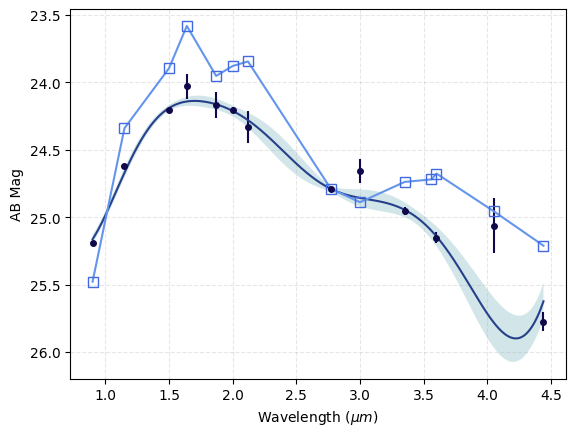

In [31]:
gpmag, gpmagerr = mag[~np.isnan(mag)], magerr[~np.isnan(magerr)]
waves = jwst_wv[~np.isnan(mag)]
gpmodel = fit_gp_model_george(waves, gpmag, gpmagerr, min_len_scale=1)
plot_sed_with_gpmodel(waves, gpmag, gpmagerr, gpmodel, 'plots/sed_george.png')
best_model = modeldf.loc[mid[np.argmin(chisq)]][['f090w', 'f115w', 'f150w', 'f164n', 'f187n', 'f200w', 'f212n', 'f277w', 'f300m', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']].to_numpy()
plt.plot(jwst_wv, best_model, marker = 's', fillstyle='none', markeredgecolor = 'royalblue', color = 'cornflowerblue', markersize = 7)
plt.savefig('plots/marcs_fit6.png', bbox_inches='tight')

### PCA

In [134]:
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [135]:
pca = PCA(n_components=5)
ica = FastICA(n_components=5)
std_scaler = StandardScaler()
mmax_scaler = MinMaxScaler()

In [136]:
fls = [i.upper()+'_mag' for i in filts]
subdf = cat[m < 26][fls]
subdf[subdf > 99] = np.nan
subdf = subdf.dropna()

In [137]:
model_mags = modeldf[filts].to_numpy().T
# stacked_mags = copy.copy(mags)
stacked_mags = np.concat([subdf.values, modeldf[filts].values]).T
icm = np.array(len(subdf)*[True] + 1331*[False])

scaled_mags = mmax_scaler.fit_transform(stacked_mags)
fit_input = scaled_mags
pca.fit(fit_input)

PCA(n_components=5)

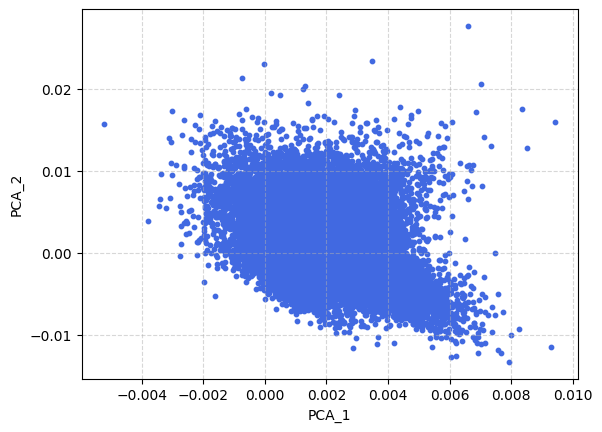

In [293]:
plt.scatter(pca.components_[0], pca.components_[1], s = 10, color = 'royalblue')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

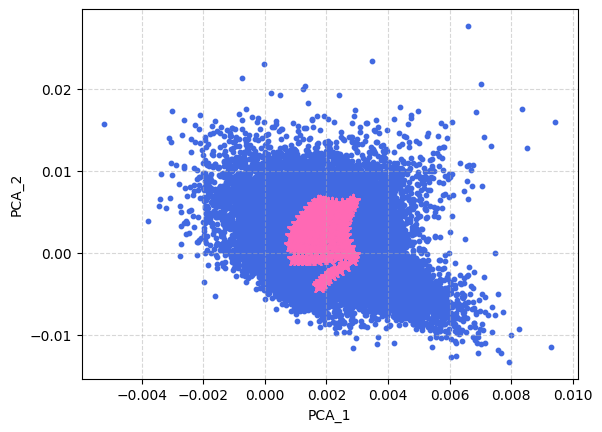

In [294]:
plt.scatter(pca.components_[0][icm], pca.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(pca.components_[0][~icm], pca.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

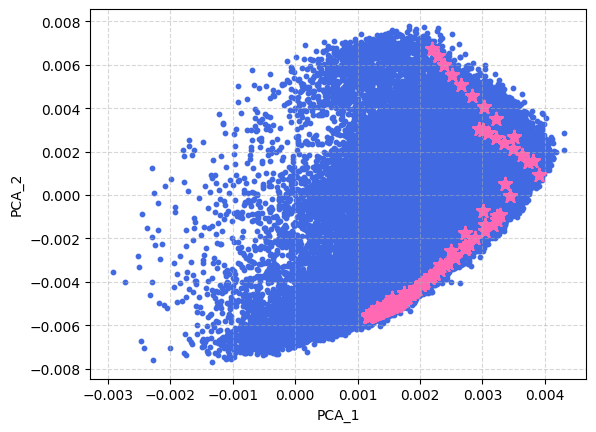

In [138]:
pcacomp0, pcacomp1 = 0, 1
plt.scatter(pca.components_[pcacomp0][icm], pca.components_[pcacomp1][icm], s = 10, color = 'royalblue')
plt.scatter(pca.components_[pcacomp0][~icm], pca.components_[pcacomp1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

In [ ]:
model_mags = np.vstack([f090w_mag, f150w_mag, f277w_mag])
smg = []
stacked_mags = np.hstack([mags, model_mags])

mask = (stacked_mags[0] < 80) & (stacked_mags[1] < 80) & (stacked_mags[2] < 80)
smg.append(stacked_mags[0][mask])
smg.append(stacked_mags[1][mask])
smg.append(stacked_mags[2][mask])
smg = np.array(smg)
stacked_mags = smg
icm = np.array(len(mags[0])*[True] + len(model_mags[0])*[False])[mask]

scaled_mags = std_scaler.fit_transform(stacked_mags)
fit_input = stacked_mags
ica.fit(fit_input)

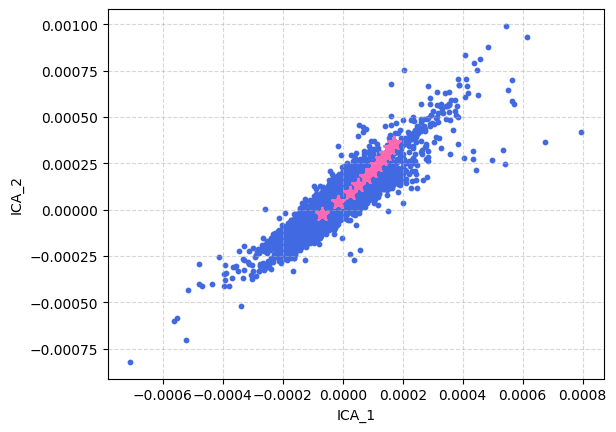

In [79]:
plt.scatter(ica.components_[0][icm], ica.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][~icm], ica.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
# plt.xlim(-1e-5, 1e-5)
# plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

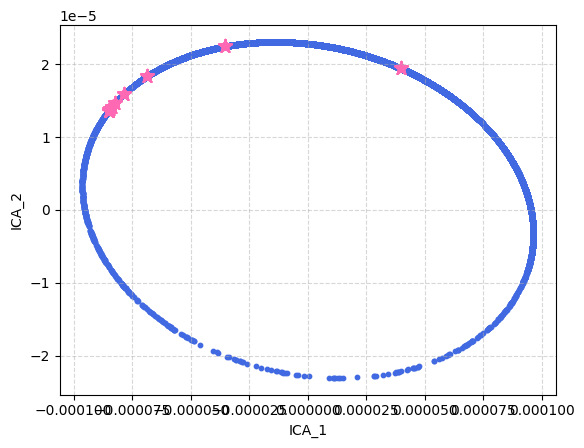

In [76]:
plt.scatter(ica.components_[0][icm], ica.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][~icm], ica.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
# plt.xlim(-1e-5, 1e-5)
# plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

In [139]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

In [159]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(stacked_mags.T)

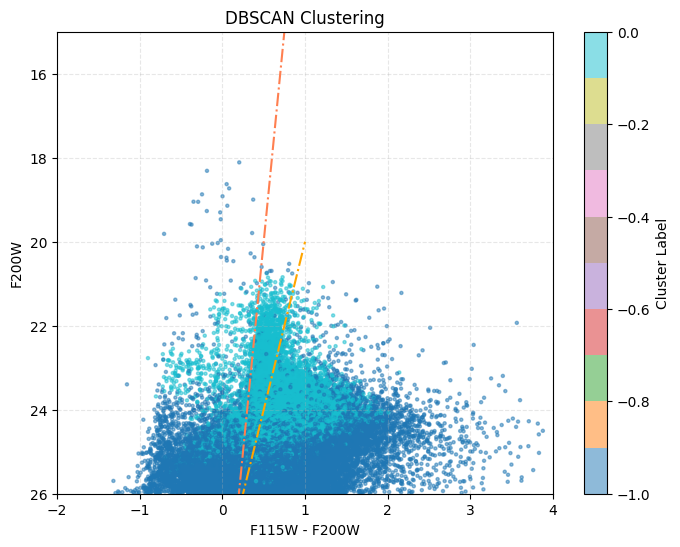

In [165]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(stacked_mags.T[icm][:, 1][labels[icm]<1] - stacked_mags.T[icm][:, 5][labels[icm]<1], stacked_mags.T[icm][:, 5][labels[icm]<1], 
                      c=labels[icm][labels[icm]<1], cmap = 'tab10', s=5, alpha=0.5)
# plt.scatter(stacked_mags.T[~icm][:, 1] - stacked_mags.T[~icm][:, 5], stacked_mags.T[~icm][:, 5], color='orange', marker = 's', s=2, alpha=0.7)

plt.axhline(26.19, color = 'red', label='TRGB', linestyle = '-.')
plt.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
plt.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -8.0, 25+3), linestyle='-.', color = 'orange')

plt.xlabel('F115W - F200W')
plt.ylabel('F200W')
plt.title('DBSCAN Clustering')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(alpha=0.3, linestyle='--')
plt.xlim(-2, 4)
plt.ylim(26, 15)
plt.show()

In [174]:
cat.loc[subdf[labels[icm] == 0].index].to_csv('data/dolphot/ngc5643/dbscan_rsg.csv', index=False)